# OPTED Reverse Dictionary — Exploratory Data Analysis

## Word and Definition Focus

The reverse-dictionary task uses a description as input and retrieves the most appropriate target word. Therefore, this notebook focuses only on the two fields directly required for that task:

- `Word` — the target name/word
- `Definition` — the description associated with the word

The raw dataset may contain other columns, but `Count` and `POS` are intentionally excluded from this analysis.

This notebook covers:

1. Dataset overview
2. Missing and invalid-value analysis
3. Duplicate and multiple-definition analysis
4. Definition-length analysis
5. Definition-vocabulary analysis
6. Definitions-per-word distribution
7. Final EDA summary and observations


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from pathlib import Path
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

FILE_PATH = Path("../data/OPTED-Dictionary.csv")

WORD_COL = "Word"
DEF_COL = "Definition"

# Load only the columns used by the reverse-dictionary task.
df = pd.read_csv(
    FILE_PATH,
    usecols=[WORD_COL, DEF_COL],
)

print("Dataset shape:", df.shape)
display(df.head(10))


Dataset shape: (176009, 2)


,Word,Definition
0,A,"""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Italic black letter etc..."
1,A,"""The name of the sixth tone in the model major scale (that in C) or the first tone of the minor scale which is named after it the scale in A minor. The second string of the violin is tuned to the..."
2,A,"""An adjective commonly called the indefinite article and signifying one or any but less emphatically."""
3,A,"""In each; to or for each; as """"""""twenty leagues a day"""""""" """"""""a hundred pounds a year"""""""" """"""""a dollar a yard"""""""" etc."""
4,A,"""In; on; at; by."""
5,A,"""In process of; in the act of; into; to; -- used with verbal substantives in -ing which begin with a consonant. This is a shortened form of the preposition an (which was used before the vowel soun..."
6,A,"""Of."""
7,A,"""A barbarous corruption of have of he and sometimes of it and of they."""
8,A,"""An expletive void of sense to fill up the meter"""
9,A-,"""A as a prefix to English words is derived from various sources. (1) It frequently signifies on or in (from an a forms of AS. on) denoting a state as in afoot on foot abed amiss asleep aground aloft"


# 1. Dataset Overview

In [38]:
overview = pd.DataFrame({
    "Column": [WORD_COL, DEF_COL],
    "Datatype": [
        str(df[WORD_COL].dtype),
        str(df[DEF_COL].dtype),
    ],
    "Non-null values": [
        int(df[WORD_COL].notna().sum()),
        int(df[DEF_COL].notna().sum()),
    ],
    "Unique values": [
        int(df[WORD_COL].nunique(dropna=True)),
        int(df[DEF_COL].nunique(dropna=True)),
    ],
})

display(overview)

print(f"Rows: {len(df):,}")
print(f"Unique raw words: {df[WORD_COL].nunique(dropna=True):,}")
print(f"Unique raw definitions: {df[DEF_COL].nunique(dropna=True):,}")


,Column,Datatype,Non-null values,Unique values
0,Word,str,176005,111596
1,Definition,str,176009,166067


Rows: 176,009
Unique raw words: 111,596
Unique raw definitions: 166,067


In [39]:
INVALID_PLACEHOLDERS = {
    "",
    '""',
    "#NAME?",
    "#VALUE!",
    "#REF!",
    "#DIV/0!",
    "#N/A",
    "#NUM!",
    "#NULL!",
}

INVALID_PLACEHOLDERS_NORMALIZED = {
    value.strip().upper()
    for value in INVALID_PLACEHOLDERS
}


def is_invalid_placeholder(value) -> bool:
    """Detect non-null blank values and known placeholder/error strings."""

    if pd.isna(value):
        return False

    normalized = str(value).strip().upper()
    return normalized in INVALID_PLACEHOLDERS_NORMALIZED


def is_invalid(value) -> bool:
    """Detect null, blank, or known placeholder/error values."""

    return pd.isna(value) or is_invalid_placeholder(value)


# 2. Missing and Invalid Values

In [40]:
missing_summary = pd.DataFrame(
    {
        "Null values": {
            WORD_COL: int(df[WORD_COL].isna().sum()),
            DEF_COL: int(df[DEF_COL].isna().sum()),
        },
        "Invalid placeholder values": {
            WORD_COL: int(df[WORD_COL].apply(is_invalid_placeholder).sum()),
            DEF_COL: int(df[DEF_COL].apply(is_invalid_placeholder).sum()),
        },
    }
)

missing_summary["Total missing/invalid"] = (
    missing_summary["Null values"]
    + missing_summary["Invalid placeholder values"]
)

display(missing_summary)


,Null values,Invalid placeholder values,Total missing/invalid
Word,4,207,211
Definition,0,2,2


In [41]:
invalid_word_rows = df[df[WORD_COL].apply(is_invalid)]
invalid_definition_rows = df[df[DEF_COL].apply(is_invalid)]

print(f"Rows with invalid words: {len(invalid_word_rows):,}")
display(invalid_word_rows.head(20))

print(f"Rows with invalid definitions: {len(invalid_definition_rows):,}")
display(invalid_definition_rows.head(20))


Rows with invalid words: 211


,Word,Definition
12568,#NAME?,"""of Baptistry"""
13583,#NAME?,"""of Bedesman"""
13587,#NAME?,"""of Bedeswoman"""
14423,#NAME?,"""of Bel-esprit"""
15549,#NAME?,"""Containing two atoms or equivalents of carbon in the molecule."""
16674,#NAME?,"""A suffix or terminal formative used principally in biological terms and signifying growth formation; as bioblast epiblast mesoblast etc."""
18442,#NAME?,"""of Boothy"""
18981,#NAME?,"""Alt. of ical"""
21102,#NAME?,"""of Bursary"""
21860,#NAME?,"""of Calcaneum"""


Rows with invalid definitions: 2


,Word,Definition
6898,Antic,""""""
114928,Piracy,""""""


# 3. Duplicate and Multiple-Definition Analysis

In [42]:
valid_word_definition_df = df[
    ~df[WORD_COL].apply(is_invalid)
    & ~df[DEF_COL].apply(is_invalid)
].copy()

duplicate_pair_mask = valid_word_definition_df.duplicated(
    subset=[WORD_COL, DEF_COL],
    keep="first",
)

print(
    "Exact duplicate word-definition pairs:",
    f"{int(duplicate_pair_mask.sum()):,}",
)

display(
    valid_word_definition_df.loc[
        duplicate_pair_mask,
        [WORD_COL, DEF_COL],
    ].head(20)
)


Exact duplicate word-definition pairs: 237


,Word,Definition
4020,Aldermanly,"""Pertaining to or like an alderman."""
4077,Alewives,"""of Alewife"""
4384,Alleys,"""of Alley"""
9599,Asphaltite,"""Asphaltic."""
11383,Awaked,"""of Awake"""
11387,Awoke,"""of Awake"""
11535,Aye,"""Alt. of Ay"""
11841,Backslid,"""of Backslide"""
12976,Barytone,"""Alt. of Baritone"""
13229,Bastinadoes,"""of Bastinado"""


In [43]:
definitions_per_word = (
    valid_word_definition_df
    .groupby(WORD_COL)[DEF_COL]
    .nunique()
    .sort_values(ascending=False)
)

multi_definition_words = definitions_per_word[
    definitions_per_word > 1
]

single_definition_words = definitions_per_word[
    definitions_per_word == 1
]

print(f"Valid unique words: {len(definitions_per_word):,}")
print(f"Words with one unique definition: {len(single_definition_words):,}")
print(f"Words with multiple unique definitions: {len(multi_definition_words):,}")

display(
    multi_definition_words
    .head(20)
    .rename("Number of Unique Definitions")
    .to_frame()
)


Valid unique words: 111,595
Words with one unique definition: 86,401
Words with multiple unique definitions: 25,194


,Number of Unique Definitions
Word,
Run,71
Set,59
Light,47
Round,46
Cast,45
Line,44
Strike,44
Rise,42
Fall,41


# 4. Definition-Length Analysis

In [44]:
valid_definition_df = valid_word_definition_df.copy()

valid_definition_df["definition_word_count"] = (
    valid_definition_df[DEF_COL]
    .astype(str)
    .str.split()
    .str.len()
)

valid_definition_df["definition_char_count"] = (
    valid_definition_df[DEF_COL]
    .astype(str)
    .str.len()
)

display(
    valid_definition_df[
        [
            "definition_word_count",
            "definition_char_count",
        ]
    ].describe()
)


,definition_word_count,definition_char_count
count,175796.000000,175796.000000
mean,11.157990,66.684703
std,10.566032,60.749742
min,1.000000,3.000000
25%,3.000000,23.000000
50%,8.000000,48.000000
75%,15.000000,90.000000
max,148.000000,807.000000


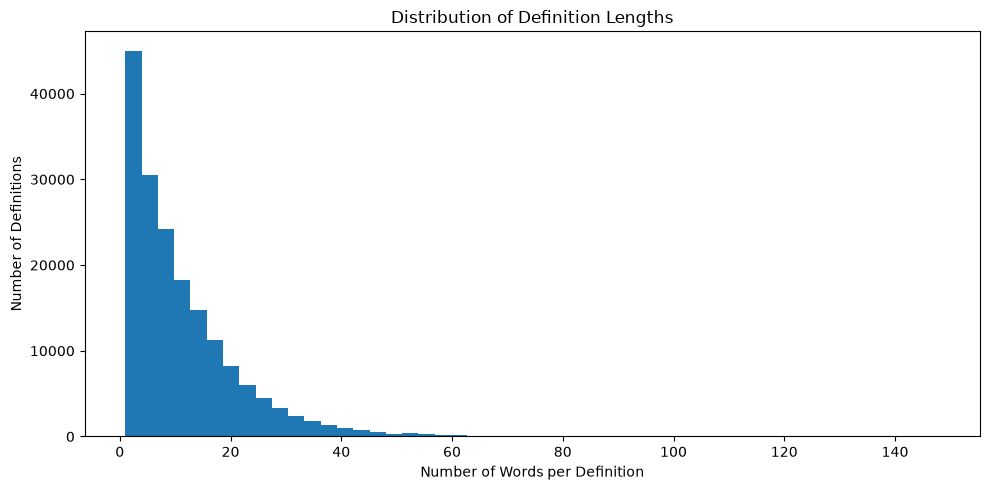

In [45]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_definition_df["definition_word_count"],
    bins=50,
)

plt.title("Distribution of Definition Lengths")
plt.xlabel("Number of Words per Definition")
plt.ylabel("Number of Definitions")
plt.tight_layout()
plt.show()


In [46]:
print("Shortest definitions:")

display(
    valid_definition_df
    .sort_values(
        ["definition_word_count", "definition_char_count"],
        ascending=True,
    )
    [
        [
            WORD_COL,
            DEF_COL,
            "definition_word_count",
            "definition_char_count",
        ]
    ]
    .head(20)
)

print("Longest definitions:")

display(
    valid_definition_df
    .sort_values(
        ["definition_word_count", "definition_char_count"],
        ascending=False,
    )
    [
        [
            WORD_COL,
            DEF_COL,
            "definition_word_count",
            "definition_char_count",
        ]
    ]
    .head(20)
)


Shortest definitions:


,Word,Definition,definition_word_count,definition_char_count
43831,Dis-,""".""",1,3
48325,Drum major,""".""",1,3
75704,Ich,"""I.""",1,4
76088,Ik,"""I.""",1,4
175115,Y,"""I.""",1,4
6,A,"""Of.""",1,5
4729,Als,"""As.""",1,5
65798,Gif,"""If.""",1,5
65916,Gin,"""If.""",1,5
72954,Hit,"""It.""",1,5


Longest definitions:


,Word,Definition,definition_word_count,definition_char_count
167708,V,"""V the twenty-second letter of the English alphabet is a vocal consonant. V and U are only varieties of the same character U being the cursive form while V is better adapted for engraving as in s...",148,797
17916,Bond,"""The union or tie of the several stones or bricks forming a wall. The bricks may be arranged for this purpose in several different ways as in English or block bond (Fig. 1) where one course consi...",147,807
141996,Siphon,"""A device consisting of a pipe or tube bent so as to form two branches or legs of unequal length by which a liquid can be transferred to a lower level as from one vessel to another over an interm...",140,749
155837,Tapeworm,"""Any one of numerous species of cestode worms belonging to Taenia and many allied genera. The body is long flat and composed of numerous segments or proglottids varying in shape those toward the ...",130,767
158992,Tide,"""The alternate rising and falling of the waters of the ocean and of bays rivers etc. connected therewith. The tide ebbs and flows twice in each lunar day or the space of a little more than twenty...",130,699
93975,Master,"""A male person having another living being so far subject to his will that he can in the main control his or its actions; -- formerly used with much more extensive application than now. (a) The e...",127,683
0,A,"""The first letter of the English and of many other alphabets. The capital A of the alphabets of Middle and Western Europe as also the small letter (a) besides the forms in Italic black letter etc...",120,667
49455,Eclipse,"""An interception or obscuration of the light of the sun moon or other luminous body by the intervention of some other body either between it and the eye or between the luminous body and that illu...",119,635
103743,Oak,"""Any tree or shrub of the genus Quercus. The oaks have alternate leaves often variously lobed and staminate flowers in catkins. The fruit is a smooth nut called an acorn which is more or less inc...",118,674
164587,Un-,"""An inseparable verbal prefix or particle. It is prefixed: (a) To verbs to express the contrary and not the simple negative of the action of the verb to which it is prefixed; as in uncoil undo un...",117,676


# 5. Definition Vocabulary Analysis

In [47]:
all_definition_text = " ".join(
    valid_definition_df[DEF_COL].astype(str)
)

tokens = re.findall(
    r"\b[a-zA-Z]+\b",
    all_definition_text.lower(),
)

token_counter = Counter(tokens)

print(f"Total alphabetic tokens: {len(tokens):,}")
print(f"Unique alphabetic tokens: {len(token_counter):,}")

top_definition_tokens = pd.DataFrame(
    token_counter.most_common(20),
    columns=["Token", "Frequency"],
)

display(top_definition_tokens)


Total alphabetic tokens: 1,957,399
Unique alphabetic tokens: 72,571


,Token,Frequency
0,of,131359
1,a,114300
2,the,111158
3,to,97375
4,or,88627
5,as,38874
6,in,37889
7,and,26215
8,an,18917
9,by,17793


In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_definition_tokens["Token"][::-1],
    top_definition_tokens["Frequency"][::-1],
)

plt.title("Top 20 Tokens in Definitions")
plt.xlabel("Frequency")
plt.ylabel("Token")
plt.tight_layout()
plt.show()


# 6. Definitions per Word Distribution

,Number of Words
Definition,
1,86401
2,13397
3,4818
4,2319
5,1341
6,933
7,567
8,413
9,299


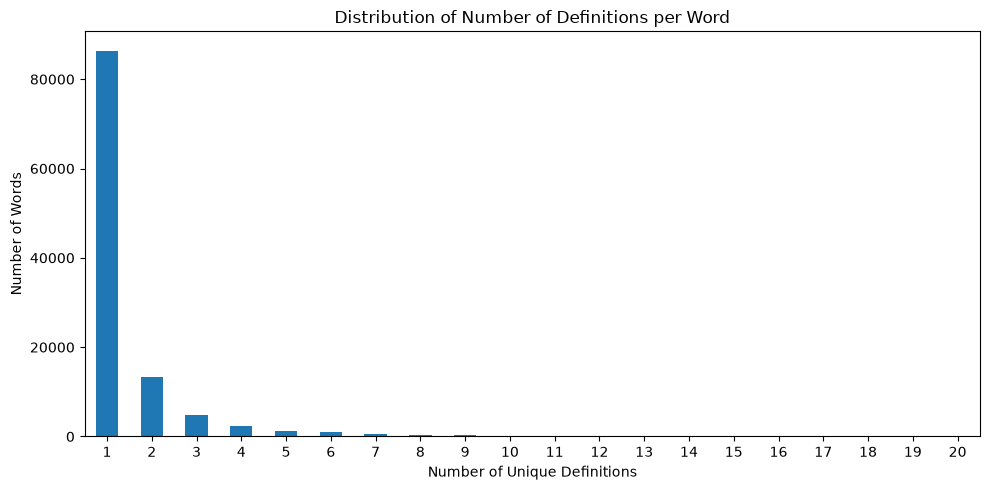

In [48]:
definitions_frequency = (
    definitions_per_word
    .value_counts()
    .sort_index()
)

display(
    definitions_frequency
    .rename("Number of Words")
    .to_frame()
)

plt.figure(figsize=(10, 5))

definitions_frequency.loc[
    definitions_frequency.index <= 20
].plot(kind="bar")

plt.title("Distribution of Number of Definitions per Word")
plt.xlabel("Number of Unique Definitions")
plt.ylabel("Number of Words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 7. EDA Summary

In [49]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Raw rows",
        "Valid word-definition rows",
        "Unique valid words",
        "Unique valid definitions",
        "Exact duplicate word-definition pairs",
        "Words with one definition",
        "Words with multiple definitions",
        "Average definition length in words",
        "Median definition length in words",
        "Definition vocabulary size",
    ],
    "Value": [
        len(df),
        len(valid_word_definition_df),
        valid_word_definition_df[WORD_COL].nunique(),
        valid_word_definition_df[DEF_COL].nunique(),
        int(duplicate_pair_mask.sum()),
        len(single_definition_words),
        len(multi_definition_words),
        round(valid_definition_df["definition_word_count"].mean(), 2),
        round(valid_definition_df["definition_word_count"].median(), 2),
        len(token_counter),
    ],
})

display(eda_summary)


,Metric,Value
0,Raw rows,176009.00
1,Valid word-definition rows,175796.00
2,Unique valid words,111595.00
3,Unique valid definitions,165876.00
4,Exact duplicate word-definition pairs,237.00
5,Words with one definition,86401.00
6,Words with multiple definitions,25194.00
7,Average definition length in words,11.16
8,Median definition length in words,8.00
9,Definition vocabulary size,72571.00


## EDA Findings and Observations

### Dataset composition

The analysis treats each record as a `Word`–`Definition` pair. A word may occur in more than one row because the same target word can have multiple distinct meanings. The exact row, word, and definition totals are reported in the EDA summary above.

### Data quality

The dataset contains a small number of unusable word or definition values, including nulls, blank strings, literal `""` values, and spreadsheet-error placeholders such as `#NAME?`. These records should be removed before building the retrieval corpus.

Exact duplicate word-definition pairs are also present. They do not add new lexical information and should be removed during preprocessing. Distinct definitions belonging to the same word are valid and must be retained.

### Definition length

The definition-length distribution is right-skewed. Most definitions are relatively short, while a smaller number are considerably longer. Extremely short, punctuation-only, or otherwise uninformative definitions should be inspected because they may not provide enough semantic information for reverse-dictionary retrieval.

Long definitions are not automatically invalid, but they may contain several clauses or details that affect how their embeddings behave.

### Multiple definitions per word

A meaningful portion of the vocabulary has more than one unique definition. This reflects normal polysemy rather than duplication.

Because the reverse-dictionary system predicts a target word, all definitions belonging to the same word must remain in the same train, validation, or test split. Splitting individual rows could place different definitions of one word into different splits and cause target-word leakage.

### Definition vocabulary

The definitions contain a large vocabulary with a strong concentration of common English function words. The vocabulary analysis is descriptive only; no stop-word removal is performed at this stage.

### EDA conclusion

The data is suitable for a reverse-dictionary project after focused preprocessing of the `Word` and `Definition` fields. The preprocessing stage should:

1. Preserve the original dataset unchanged.
2. Remove rows with invalid words or unusable definitions.
3. Normalize whitespace and wrapping quotation artifacts.
4. Remove duplicate word-definition pairs.
5. Retain distinct definitions associated with the same word.
6. Create train, validation, and test splits by unique word.
7. Use the cleaned definition as the retrieval text and the cleaned word as the target label.

`Count` and `POS` are intentionally excluded from the modelling pipeline for the current project scope.
